# Member C Drug Recommendation Notebook

This notebook is organized as a clear experiment story for Member C's scope:
1. build richer drug representations from the enhanced drug table
2. establish a simple and interpretable baseline
3. show why pure KNN retrieval is not enough
4. use a hybrid pipeline as the current main method
5. keep Random Forest and DDI as later extensions


## 1. Imports and Paths

In [1]:
from pathlib import Path
import ast
import json
import warnings
import numpy as np
import pandas as pd

# Optional ML / embedding imports
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.metrics.pairwise import cosine_similarity
# from transformers import AutoTokenizer, AutoModel

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT.parent / 'data' if (PROJECT_ROOT.parent / 'data').exists() else PROJECT_ROOT / 'data'
INPUT_CSV = DATA_DIR / 'enhanced_drug_table_v1.csv'
DISEASE_KEYS_PATH = PROJECT_ROOT / 'disease_keys.json'

# Notebook mode toggle
# PRESENTATION_MODE=True: suppress noisy warnings/logs for clean screenshots
# DEBUG_MODE=True: keep warnings visible while debugging
PRESENTATION_MODE = True
DEBUG_MODE = not PRESENTATION_MODE

if PRESENTATION_MODE:
    warnings.filterwarnings('ignore', category=RuntimeWarning)
else:
    warnings.filterwarnings('default', category=RuntimeWarning)

print('PROJECT_ROOT =', PROJECT_ROOT)
print('DATA_DIR =', DATA_DIR)
print('INPUT_CSV exists =', INPUT_CSV.exists())
print('DISEASE_KEYS_PATH exists =', DISEASE_KEYS_PATH.exists())
print('PRESENTATION_MODE =', PRESENTATION_MODE)


PROJECT_ROOT = /Users/jayden/Desktop/7012 datamining and text/project_march/ARIN7102_Group_Project
DATA_DIR = /Users/jayden/Desktop/7012 datamining and text/project_march/data
INPUT_CSV exists = True
DISEASE_KEYS_PATH exists = True
PRESENTATION_MODE = True


## 2. Load Data

In [2]:
df = pd.read_csv(INPUT_CSV)
df.head()


,drug_name,generic_name,drug_classes,brand_names,side_effects,activity,rx_otc,pregnancy_category,csa,alcohol,related_drugs,avg_rating,total_reviews,original_conditions,medical_condition_description,matched_disease_keys,matched_symptoms,symptom_severity,disease_description
0,7t gummy es chewable tablets,acetaminophen,NaN,NaN,NaN,3%,Rx/OTC,C,N,X,Buprenex: https://www.drugs.com/buprenex.html ...,NaN,0.0,"[""Pain""]",Pain An unpleasant sensory and emotional exper...,"[""others""]","[""burning_sensation"", ""constant_pain"", ""crampi...",{},NaN
1,a + d cracked skin relief,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,1.0,"[""Bacterial Skin Infection""]",NaN,"[""others""]","[""enlarged_lymph_nodes"", ""fever"", ""pain_or_ten...",{},NaN
2,a / b otic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,2.0,"[""Otitis Media""]",NaN,"[""others""]","[""balance_problems"", ""ear_discharge"", ""ear_pai...","{""headache"": 3, ""irritability"": 2, ""loss_of_ap...",NaN
3,a-g profen,ibuprofen (oral route),Nonsteroidal anti-inflammatory drugs,NaN,"Along with its needed effects, a medicine may ...",3%,Rx/OTC,C,N,X,NaN,NaN,0.0,"[""Osteoarthritis""]","Osteoarthritis Other names: Arthritis, Osteoar...","[""arthritis""]","[""movement_stiffness"", ""muscle_weakness"", ""pai...","{""movement_stiffness"": 5, ""muscle_weakness"": 2...",[arthritis] Arthritis is the swelling and tend...
4,a-phedrin,pseudoephedrine and triprolidine,Upper respiratory combinations,"Aphedrid, Aprodine, Histafed, Vi-Sudo",hives ; difficult breathing; swelling of your ...,1%,Rx/OTC,C,N,X,NaN,NaN,0.0,"[""Colds & Flu""]",Cold Symptoms Other names: Cold; Common Cold; ...,"[""common_cold""]","[""chest_pain"", ""chills"", ""congestion"", ""contin...","{""chest_pain"": 7, ""chills"": 3, ""congestion"": 5...",[common_cold] The common cold is a viral infec...


In [3]:
print('shape =', df.shape)
print('columns =')
for col in df.columns:
    print('-', col)


shape = (5595, 19)
columns =
- drug_name
- generic_name
- drug_classes
- brand_names
- side_effects
- activity
- rx_otc
- pregnancy_category
- csa
- alcohol
- related_drugs
- avg_rating
- total_reviews
- original_conditions
- medical_condition_description
- matched_disease_keys
- matched_symptoms
- symptom_severity
- disease_description


## 3. Helper Functions

These helpers normalize the raw CSV fields for later matching and embedding.

In [4]:
def parse_list_like(value):
    if pd.isna(value):
        return []
    text = str(value).strip()
    if not text:
        return []
    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, list):
            return [str(item).strip() for item in parsed if str(item).strip()]
    except (ValueError, SyntaxError):
        pass
    return [text]


def clean_text(value):
    if pd.isna(value):
        return ''
    return ' '.join(str(value).strip().split())


def normalize_symptom_name(symptom):
    return str(symptom).strip().lower().replace('_', ' ')


def safe_cosine_scores(candidate_vecs, query_vec, debug=DEBUG_MODE):
    candidate_vecs = np.asarray(candidate_vecs, dtype=np.float32)
    query_vec = np.asarray(query_vec, dtype=np.float32)

    if candidate_vecs.ndim != 2:
        raise ValueError(f'candidate_vecs should be 2D, got shape={candidate_vecs.shape}')
    if query_vec.ndim == 1:
        query_vec = query_vec.reshape(1, -1)
    if query_vec.ndim != 2:
        raise ValueError(f'query_vec should be 2D, got shape={query_vec.shape}')

    c_norm = np.linalg.norm(candidate_vecs, axis=1, keepdims=True)
    q_norm = np.linalg.norm(query_vec, axis=1, keepdims=True)

    zero_c = int((c_norm == 0).sum())
    zero_q = int((q_norm == 0).sum())
    if debug and (zero_c > 0 or zero_q > 0):
        print(f'[debug] zero-norm vectors detected: candidates={zero_c}, queries={zero_q}')

    c_norm = np.where(c_norm == 0, 1.0, c_norm)
    q_norm = np.where(q_norm == 0, 1.0, q_norm)

    with np.errstate(divide='ignore', invalid='ignore', over='ignore'):
        scores = ((candidate_vecs / c_norm) @ (query_vec / q_norm).T).flatten()

    scores = np.nan_to_num(scores, nan=0.0, posinf=0.0, neginf=0.0)
    return scores


## 4. Build Structured Columns

In [5]:
df['disease_key_list'] = df['matched_disease_keys'].apply(parse_list_like)
df['symptom_list'] = df['matched_symptoms'].apply(parse_list_like)
df['symptom_list_normalized'] = df['symptom_list'].apply(lambda items: [normalize_symptom_name(x) for x in items])
df[['drug_name', 'disease_key_list', 'symptom_list_normalized']].head()


,drug_name,disease_key_list,symptom_list_normalized
0,7t gummy es chewable tablets,[others],"[burning sensation, constant pain, cramping pa..."
1,a + d cracked skin relief,[others],"[enlarged lymph nodes, fever, pain or tenderne..."
2,a / b otic,[others],"[balance problems, ear discharge, ear pain, fe..."
3,a-g profen,[arthritis],"[movement stiffness, muscle weakness, painful ..."
4,a-phedrin,[common_cold],"[chest pain, chills, congestion, continuous sn..."


## 5. Build Semantic Text for Each Drug

This is the text you can later feed into TF-IDF, PubMedBERT, or another embedding model.
- 先构造更合理的药物表示
    用 drug_name + generic_name + drug_classes + matched_symptoms + disease_description + side_effects 一起表示药，而不是只用药名。

- 再做聚类或相似性分析
    这样聚出来的类，才更可能对应：

    - 同成分药
    - 同类药
    - 治疗相近 symptom 的药


- 最后再解释每个 cluster
    比如看某个 cluster 里：
    最常见的 generic_name
    最常见的 drug_classes
    最常见的 matched_symptoms

这样你们才能讲“这一类药主要治疗 fever/headache/cough”，“这一类药主要成分接近 acetaminophen / ibuprofen”。

In [6]:
def build_semantic_text(row):
    parts = []
    if clean_text(row.get('drug_name')):
        parts.append(f"Drug name: {clean_text(row.get('drug_name'))}.")
    if clean_text(row.get('generic_name')):
        parts.append(f"Generic ingredient: {clean_text(row.get('generic_name'))}.")
    if clean_text(row.get('drug_classes')):
        parts.append(f"Drug classes: {clean_text(row.get('drug_classes'))}.")
    if row.get('disease_key_list'):
        parts.append('Related diseases: ' + ', '.join(row['disease_key_list']) + '.')
    if row.get('symptom_list_normalized'):
        parts.append('Target symptoms: ' + ', '.join(row['symptom_list_normalized'][:20]) + '.')
    if clean_text(row.get('medical_condition_description')):
        parts.append(f"Medical condition context: {clean_text(row.get('medical_condition_description'))}.")
    if clean_text(row.get('disease_description')):
        parts.append(f"Disease description: {clean_text(row.get('disease_description'))}.")
    if clean_text(row.get('side_effects')):
        parts.append(f"Known side effects: {clean_text(row.get('side_effects'))}.")
    return ' '.join(parts) if parts else '[MASK]'


df['semantic_text'] = df.apply(build_semantic_text, axis=1)
df[['drug_name', 'semantic_text']].head(3)


,drug_name,semantic_text
0,7t gummy es chewable tablets,Drug name: 7t gummy es chewable tablets. Gener...
1,a + d cracked skin relief,Drug name: a + d cracked skin relief. Related ...
2,a / b otic,Drug name: a / b otic. Related diseases: other...


## 6. Step 1: Baseline Retrieval

Start with a simple, interpretable baseline before adding semantic retrieval.

In [7]:
def baseline_filter(df, disease_labels, symptom_terms):
    disease_labels = {str(x).strip() for x in disease_labels}
    symptom_terms = {normalize_symptom_name(x) for x in symptom_terms}

    def match_row(row):
        disease_overlap = len(set(row['disease_key_list']) & disease_labels)
        symptom_overlap = len(set(row['symptom_list_normalized']) & symptom_terms)
        return disease_overlap, symptom_overlap

    scores = df.apply(match_row, axis=1, result_type='expand')
    scores.columns = ['disease_overlap', 'symptom_overlap']
    result = pd.concat([df.copy(), scores], axis=1)
    result = result[(result['disease_overlap'] > 0) | (result['symptom_overlap'] > 0)].copy()
    result['avg_rating_filled'] = result['avg_rating'].fillna(0)
    result = result.sort_values(
        by=['disease_overlap', 'symptom_overlap', 'avg_rating_filled'],
        ascending=[False, False, False]
    )
    return result


In [8]:
# Example query from Team 1 output
example_diseases = ['common_cold']
example_symptoms = ['fever', 'headache', 'cough']

baseline_results = baseline_filter(df, example_diseases, example_symptoms)
baseline_results[['drug_name', 'disease_overlap', 'symptom_overlap', 'avg_rating']].head(10)


,drug_name,disease_overlap,symptom_overlap,avg_rating
67,acetaminophen / dextromethorphan / guaifenesin...,1,2,10.0
68,acetaminophen / dextromethorphan / guaifenesin...,1,2,10.0
116,acrivastine / pseudoephedrine,1,2,10.0
137,acyclovir / hydrocortisone,1,2,10.0
213,alahist lq,1,2,10.0
265,allegra odt,1,2,10.0
276,allergy dn pe,1,2,10.0
397,ampicillin,1,2,10.0
483,arcalyst,1,2,10.0
908,brompheniramine / codeine / phenylephrine,1,2,10.0


## 7. Step 2: Build / Load Embeddings

This block prepares the embedding matrix used by the later KNN and hybrid experiments.

In [9]:
# Baseline option: TF-IDF
# vectorizer = TfidfVectorizer(max_features=4096, ngram_range=(1, 2))
# drug_embeddings = vectorizer.fit_transform(df['semantic_text'])

# Later option: PubMedBERT / SapBERT
# tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
# model = AutoModel.from_pretrained(MODEL_NAME)
# drug_embeddings = ...

from drug_embedding_engine import DrugEmbeddingEngine

EMBEDDING_FILE = PROJECT_ROOT / 'drug_comprehensive_embeddings.npy'

# 初始化引擎 (首次运行会自动从 HuggingFace 下载 PubMedBERT 模型)
engine = DrugEmbeddingEngine()

if EMBEDDING_FILE.exists():
    print(f"发现已有 embedding 文件，直接加载: {EMBEDDING_FILE}")
    drug_embeddings = engine.load('drug_comprehensive_embeddings.npy')
else:
    print("未发现本地 embedding 文件，开始全量编码...")
    drug_embeddings = engine.encode(df['semantic_text'].tolist())
    engine.save(drug_embeddings, 'drug_comprehensive_embeddings.npy')

# 快速查看结果
print(f"向量矩阵维度: {drug_embeddings.shape}")  # 预期: (药物总数, 768)


[DrugEmbeddingEngine] 设备: mps
[DrugEmbeddingEngine] 正在加载模型: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[DrugEmbeddingEngine] 模型加载完成 
发现已有 embedding 文件，直接加载: /Users/jayden/Desktop/7012 datamining and text/project_march/ARIN7102_Group_Project/drug_comprehensive_embeddings.npy
[DrugEmbeddingEngine] 已加载: /Users/jayden/Desktop/7012 datamining and text/project_march/ARIN7102_Group_Project/drug_comprehensive_embeddings.npy  (shape=(5595, 768))
向量矩阵维度: (5595, 768)


## 8. Step 3: Retrieval Experiments

In [10]:
def query_drugs(disease_labels, symptom_terms, top_k=10):
    """
    Final interface for Team 1 -> Team 2 integration.

    Inputs:
    - disease_labels: list[str]
    - symptom_terms: list[str]

    Outputs:
    - ranked candidate drug DataFrame
    """
    candidates = baseline_filter(df, disease_labels, symptom_terms)

    # TODO: add embedding retrieval / re-ranking here
    
    # TODO: add DDI filtering here

    columns = ['drug_name', 'generic_name', 'disease_overlap', 'symptom_overlap', 'avg_rating']
    return candidates[columns].head(top_k)


query_drugs(['common_cold'], ['fever', 'headache', 'cough'], top_k=5)


,drug_name,generic_name,disease_overlap,symptom_overlap,avg_rating
67,acetaminophen / dextromethorphan / guaifenesin...,"acetaminophen, dextromethorphan, guaifenesin, ...",1,2,10.0
68,acetaminophen / dextromethorphan / guaifenesin...,"acetaminophen, dextromethorphan, guaifenesin, ...",1,2,10.0
116,acrivastine / pseudoephedrine,NaN,1,2,10.0
137,acyclovir / hydrocortisone,NaN,1,2,10.0
213,alahist lq,NaN,1,2,10.0


### 8.1 Pure KNN Retrieval (Failure Case)

In [11]:
from drug_knn_retriever import DrugKNNRetriever

# 构建 Faiss 索引 (挂载 Block 7 生成的向量矩阵)
retriever = DrugKNNRetriever(drug_embeddings, df)

# ============================================================
# 升级版 query_drugs: KNN 召回 + Baseline 交叉验证
# ============================================================
def query_drugs(disease_labels, symptom_terms, top_k=10):
    """
    终极接口: 小队一传来病症 → 我们推荐最匹配的药。

    Pipeline:
      1. Faiss KNN 语义召回 Top 20 (传统 ML: KNN)
      2. Baseline 精确匹配交叉验证 (Intersection)
      3. 综合排序输出 Top K
    """
    # Step 1: KNN 语义召回
    knn_results = retriever.query_from_labels(
        disease_labels, symptom_terms, engine, top_k=top_k * 2
    )

    # Step 2: 补充 Baseline 精确匹配得分
    from drug_embedding_engine import DrugEmbeddingEngine
    disease_set = {str(x).strip() for x in disease_labels}
    symptom_set = {normalize_symptom_name(x) for x in symptom_terms}

    def calc_overlap(row):
        d_overlap = len(set(row.get('disease_key_list', [])) & disease_set)
        s_overlap = len(set(row.get('symptom_list_normalized', [])) & symptom_set)
        return d_overlap, s_overlap

    overlaps = knn_results.apply(calc_overlap, axis=1, result_type='expand')
    overlaps.columns = ['disease_overlap', 'symptom_overlap']
    knn_results = pd.concat([knn_results, overlaps], axis=1)

    # Step 3: 综合排序 (KNN相似度 + 精确匹配数 + 评分)
    knn_results['avg_rating_filled'] = knn_results['avg_rating'].fillna(0)
    knn_results = knn_results.sort_values(
        by=['disease_overlap', 'similarity_score', 'symptom_overlap', 'avg_rating_filled'],
        ascending=[False, False, False, False]
    )

    # TODO: Phase 3 - 传统 ML 重排 (Random Forest / NN)
    # TODO: Phase 4 - DDI 药物冲突拦截 (SVM)

    columns = ['drug_name', 'generic_name', 'similarity_score',
               'disease_overlap', 'symptom_overlap', 'avg_rating']
    return knn_results[columns].head(top_k)


# ============================================================
# 测试一下！
# ============================================================
print("=" * 60)
print("测试: 感冒 + 发烧头痛咳嗽")
print("=" * 60)
query_drugs(['common_cold'], ['fever', 'headache', 'cough'], top_k=5)


[DrugKNNRetriever] Faiss 索引构建完成 
  药物总数: 5595
  向量维度: 768
  索引类型: IndexFlatIP (余弦相似度)
测试: 感冒 + 发烧头痛咳嗽
[KNN Query] Related diseases: common_cold. Target symptoms: fever, headache, cough.


Encoding drugs: 100%|██████████| 1/1 [00:00<00:00,  6.68it/s]

[DrugEmbeddingEngine] 编码完成: shape = (1, 768)


,drug_name,generic_name,similarity_score,disease_overlap,symptom_overlap,avg_rating
0,hepatitis a adult vaccine,NaN,0.976774,0,0,NaN
1,radiaplexrx,NaN,0.976576,0,0,6.5
2,prednisolone / sulfacetamide sodium,NaN,0.976291,0,0,10.0
3,hepatitis a pediatric vaccine,NaN,0.976162,0,0,NaN
4,orapred,NaN,0.975519,0,0,8.5


In [12]:
# ============================================================
# 对比实验: Baseline vs KNN 召回
# ============================================================
test_diseases = ['common_cold']
test_symptoms = ['fever', 'headache', 'cough']
TOP_K = 10

print("=" * 70)
print(" Baseline (纯文字交集匹配)")
print("=" * 70)
baseline_res = baseline_filter(df, test_diseases, test_symptoms)
baseline_top = baseline_res[['drug_name', 'disease_overlap', 'symptom_overlap', 'avg_rating']].head(TOP_K)
display(baseline_top)

print()
print("=" * 70)
print(" KNN 语义召回 (Faiss + PubMedBERT)")
print("=" * 70)
knn_res = retriever.query_from_labels(test_diseases, test_symptoms, engine, top_k=TOP_K)
knn_top = knn_res[['drug_name', 'similarity_score', 'avg_rating']].head(TOP_K)
display(knn_top)

# 对比: 两种方法推荐了哪些不同的药？
print()
print("=" * 70)
print(" 差异分析")
print("=" * 70)
baseline_drugs = set(baseline_top['drug_name'])
knn_drugs = set(knn_top['drug_name'])

both = baseline_drugs & knn_drugs
only_baseline = baseline_drugs - knn_drugs
only_knn = knn_drugs - baseline_drugs

print(f" 两者都推荐的药 ({len(both)}个): {both}")
print(f" 仅 Baseline 推荐 ({len(only_baseline)}个): {only_baseline}")
print(f" 仅 KNN 语义召回 ({len(only_knn)}个): {only_knn}")


 Baseline (纯文字交集匹配)


,drug_name,disease_overlap,symptom_overlap,avg_rating
67,acetaminophen / dextromethorphan / guaifenesin...,1,2,10.0
68,acetaminophen / dextromethorphan / guaifenesin...,1,2,10.0
116,acrivastine / pseudoephedrine,1,2,10.0
137,acyclovir / hydrocortisone,1,2,10.0
213,alahist lq,1,2,10.0
265,allegra odt,1,2,10.0
276,allergy dn pe,1,2,10.0
397,ampicillin,1,2,10.0
483,arcalyst,1,2,10.0
908,brompheniramine / codeine / phenylephrine,1,2,10.0



 KNN 语义召回 (Faiss + PubMedBERT)
[KNN Query] Related diseases: common_cold. Target symptoms: fever, headache, cough.


Encoding drugs: 100%|██████████| 1/1 [00:00<00:00, 52.90it/s]

[DrugEmbeddingEngine] 编码完成: shape = (1, 768)


,drug_name,similarity_score,avg_rating
0,hepatitis a adult vaccine,0.976774,NaN
1,radiaplexrx,0.976576,6.50
2,prednisolone / sulfacetamide sodium,0.976291,10.00
3,hepatitis a pediatric vaccine,0.976162,NaN
4,orapred,0.975519,8.50
5,dexamethasone / tobramycin,0.974215,7.33
6,paromomycin,0.973461,7.33
7,hylira,0.973206,10.00
8,insulin aspart / insulin aspart protamine,0.970384,10.00
9,ddavp rhinal tube,0.970223,10.00



 差异分析
 两者都推荐的药 (0个): set()
 仅 Baseline 推荐 (10个): {'acrivastine / pseudoephedrine', 'ampicillin', 'acetaminophen / dextromethorphan / guaifenesin / pseudoephedrine', 'acetaminophen / dextromethorphan / guaifenesin / phenylephrine', 'brompheniramine / codeine / phenylephrine', 'arcalyst', 'allegra odt', 'allergy dn pe', 'acyclovir / hydrocortisone', 'alahist lq'}
 仅 KNN 语义召回 (10个): {'hepatitis a pediatric vaccine', 'ddavp rhinal tube', 'hylira', 'dexamethasone / tobramycin', 'paromomycin', 'hepatitis a adult vaccine', 'prednisolone / sulfacetamide sodium', 'radiaplexrx', 'orapred', 'insulin aspart / insulin aspart protamine'}


### 8.2 Hybrid Pipeline: Baseline 粗筛 + KNN 精排 (Current Main Method)

**为什么需要 8.2？**

Block 8.1 暴露了一个经典问题：纯 KNN 语义召回在查询文本极短、候选库极大时失效。
所有药物的 similarity_score 都挤在 0.970~0.976 之间（差距仅 0.006），模型无法区分。

原因是：查询文本只有十几个词，而每款药的 semantic_text 有几百个词。
BERT 的 [CLS] 向量在这种极度不对称的情况下，余弦相似度趋于退化。

**解决方案：双层漏斗（这也正是白板图上画的 Intersection + KNN 逻辑）**
1. **第一层粗筛 (Baseline)**：用精确文字匹配，先锁定"疾病和症状确实对得上"的候选药（几十款）
2. **第二层精排 (KNN)**：在这几十款里，用 PubMedBERT 语义相似度做**二次排序**，把药理最相关的推到最前面

这样既保证了召回的准确性，又利用了大模型的语义理解能力做差异化排序。


In [13]:
# ============================================================
# 8.2 Hybrid: Baseline 粗筛 → KNN 精排
# ============================================================

def query_drugs_hybrid(disease_labels, symptom_terms, top_k=10):
    """
    双层漏斗推荐引擎:
      Layer 1 (Baseline): 精确匹配过滤 → 锁定对症候选药
      Layer 2 (KNN):      语义相似度重排 → 挑出药理最优解
    """
    # ── Layer 1: Baseline 粗筛 ──
    candidates = baseline_filter(df, disease_labels, symptom_terms)
    if len(candidates) == 0:
        print(" Baseline 未找到任何匹配药物")
        return pd.DataFrame()

    print(f"[Layer 1] Baseline 粗筛命中: {len(candidates)} 款候选药")

    # ── Layer 2: KNN 精排 ──
    # 取出候选药在原始 df 中的索引，提取对应的预计算向量
    candidate_indices = candidates.index.tolist()
    candidate_vecs = drug_embeddings[candidate_indices].copy().astype(np.float32)

    # 构建查询向量
    query_text = ""
    if disease_labels:
        query_text += "Related diseases: " + ", ".join(disease_labels) + ". "
    if symptom_terms:
        query_text += "Target symptoms: " + ", ".join(symptom_terms) + "."

    query_vec = engine.encode_query(query_text).astype(np.float32)

    # 归一化后算余弦相似度
    import faiss
    faiss.normalize_L2(candidate_vecs)
    faiss.normalize_L2(query_vec)
    scores = (candidate_vecs @ query_vec.T).flatten()

    candidates = candidates.copy()
    candidates['knn_score'] = scores

    # ── 综合排序: 疾病命中 > KNN语义 > 症状命中 > 评分 ──
    candidates['avg_rating_filled'] = candidates['avg_rating'].fillna(0)
    candidates = candidates.sort_values(
        by=['disease_overlap', 'knn_score', 'symptom_overlap', 'avg_rating_filled'],
        ascending=[False, False, False, False]
    )

    print(f"[Layer 2] KNN 精排完成 ")

    cols = ['drug_name', 'disease_overlap', 'symptom_overlap',
            'knn_score', 'avg_rating']
    return candidates[cols].head(top_k)


# ============================================================
# 测试对比
# ============================================================
test_diseases = ['common_cold']
test_symptoms = ['fever', 'headache', 'cough']

print("=" * 60)
print(" 8.1 纯 KNN（有问题的结果）")
print("=" * 60)
knn_only = retriever.query_from_labels(test_diseases, test_symptoms, engine, top_k=5)
display(knn_only[['drug_name', 'similarity_score', 'avg_rating']])

print()
print("=" * 60)
print(" 8.2 Hybrid（Baseline 粗筛 + KNN 精排）")
print("=" * 60)
hybrid = query_drugs_hybrid(test_diseases, test_symptoms, top_k=5)
display(hybrid)


 8.1 纯 KNN（有问题的结果）
[KNN Query] Related diseases: common_cold. Target symptoms: fever, headache, cough.


Encoding drugs: 100%|██████████| 1/1 [00:00<00:00, 109.03it/s]

[DrugEmbeddingEngine] 编码完成: shape = (1, 768)


,drug_name,similarity_score,avg_rating
0,hepatitis a adult vaccine,0.976774,NaN
1,radiaplexrx,0.976576,6.5
2,prednisolone / sulfacetamide sodium,0.976291,10.0
3,hepatitis a pediatric vaccine,0.976162,NaN
4,orapred,0.975519,8.5



 8.2 Hybrid（Baseline 粗筛 + KNN 精排）
[Layer 1] Baseline 粗筛命中: 2083 款候选药


Encoding drugs: 100%|██████████| 1/1 [00:00<00:00, 55.09it/s]

[DrugEmbeddingEngine] 编码完成: shape = (1, 768)
[Layer 2] KNN 精排完成 


,drug_name,disease_overlap,symptom_overlap,knn_score,avg_rating
5262,vanatab dx,1,2,0.969495,9.00
2730,"influenza virus vaccine, h5n1",1,2,0.965739,NaN
3524,nasacort aq,1,2,0.965299,9.67
630,ayr saline nasal,1,2,0.963061,3.20
3769,orajel,1,2,0.962838,8.00


In [14]:
# ============================================================
# 8.2 修复版: 更严格的粗筛 + 安全的 KNN 精排
# ============================================================

def query_drugs_hybrid_v2(disease_labels, symptom_terms, top_k=10):
    """
    改进版双层漏斗:
      Layer 1: 必须命中疾病 (disease_overlap > 0), 且至少命中1个症状
      Layer 2: KNN 精排 (带零向量保护)
    """
    # ── Layer 1: 严格粗筛 ──
    candidates = baseline_filter(df, disease_labels, symptom_terms)
    # 关键改进: 必须命中疾病, 不能光靠症状混进来
    candidates = candidates[candidates['disease_overlap'] > 0].copy()

    if len(candidates) == 0:
        print(" 没有找到同时匹配疾病的药物, 放宽为仅症状匹配")
        candidates = baseline_filter(df, disease_labels, symptom_terms)

    print(f"[Layer 1] 严格粗筛命中: {len(candidates)} 款候选药")

    # ── Layer 2: KNN 精排 (带保护) ──
    candidate_indices = candidates.index.tolist()
    candidate_vecs = drug_embeddings[candidate_indices].copy().astype(np.float32)

    # 构建查询向量
    parts = []
    if disease_labels:
        parts.append("Related diseases: " + ", ".join(disease_labels) + ".")
    if symptom_terms:
        parts.append("Target symptoms: " + ", ".join(symptom_terms) + ".")
    query_vec = engine.encode_query(" ".join(parts)).astype(np.float32)

    # 安全归一化 (防止零向量除以零)
    import faiss
    norms = np.linalg.norm(candidate_vecs, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1, norms)  # 零向量的 norm 设为1, 避免除零
    candidate_vecs_safe = candidate_vecs / norms

    q_norm = np.linalg.norm(query_vec, axis=1, keepdims=True)
    q_norm = np.where(q_norm == 0, 1, q_norm)
    query_vec_safe = query_vec / q_norm

    scores = (candidate_vecs_safe @ query_vec_safe.T).flatten()
    candidates['knn_score'] = scores

    # ── 综合排序 ──
    candidates['avg_rating_filled'] = candidates['avg_rating'].fillna(0)
    candidates = candidates.sort_values(
        by=['disease_overlap', 'symptom_overlap', 'knn_score', 'avg_rating_filled'],
        ascending=[False, False, False, False]
    )

    print(f"[Layer 2] KNN 精排完成  (无 Warning)")

    cols = ['drug_name', 'disease_overlap', 'symptom_overlap', 'knn_score', 'avg_rating']
    return candidates[cols].head(top_k)


# ============================================================
# 测试
# ============================================================
print("=" * 60)
print(" 8.2 v2 (严格粗筛 + 安全 KNN 精排)")
print("=" * 60)
result = query_drugs_hybrid_v2(['common_cold'], ['fever', 'headache', 'cough'], top_k=10)
display(result)


 8.2 v2 (严格粗筛 + 安全 KNN 精排)
[Layer 1] 严格粗筛命中: 511 款候选药


Encoding drugs: 100%|██████████| 1/1 [00:00<00:00, 48.79it/s]

[DrugEmbeddingEngine] 编码完成: shape = (1, 768)
[Layer 2] KNN 精排完成  (无 Warning)


,drug_name,disease_overlap,symptom_overlap,knn_score,avg_rating
5262,vanatab dx,1,2,0.969495,9.00
2730,"influenza virus vaccine, h5n1",1,2,0.965739,NaN
3524,nasacort aq,1,2,0.965299,9.67
630,ayr saline nasal,1,2,0.963061,3.20
3769,orajel,1,2,0.962838,8.00
4362,retre-gel,1,2,0.962716,10.00
2252,flecainide,1,2,0.962493,7.92
283,allerx dose pack df,1,2,0.962402,9.60
3211,maxifed dm,1,2,0.961861,8.00
2731,"influenza virus vaccine, inactivated",1,2,0.961520,6.67


### 8.3 Quick Tests Across Multiple Diseases

In [15]:
test_cases = [
    (['common_cold'], ['fever', 'headache', 'cough']),
    (['diabetes'], ['fatigue', 'weight_loss', 'blurred_vision']),
    (['hypertension'], ['headache', 'dizziness', 'chest_pain']),
    (['migraine'], ['headache', 'nausea', 'sensitivity_to_light']),
    (['acne'], ['skin_rash', 'pimple']),
]

for diseases, symptoms in test_cases:
    print(f"\n{'='*60}")
    print(f" Disease: {diseases}  |  Symptoms: {symptoms}")
    print(f"{'='*60}")
    result = query_drugs_hybrid_v2(diseases, symptoms, top_k=3)
    display(result)



 Disease: ['common_cold']  |  Symptoms: ['fever', 'headache', 'cough']
[Layer 1] 严格粗筛命中: 511 款候选药


Encoding drugs: 100%|██████████| 1/1 [00:00<00:00, 104.92it/s]

[DrugEmbeddingEngine] 编码完成: shape = (1, 768)
[Layer 2] KNN 精排完成  (无 Warning)


,drug_name,disease_overlap,symptom_overlap,knn_score,avg_rating
5262,vanatab dx,1,2,0.969495,9.00
2730,"influenza virus vaccine, h5n1",1,2,0.965739,NaN
3524,nasacort aq,1,2,0.965299,9.67



 Disease: ['diabetes']  |  Symptoms: ['fatigue', 'weight_loss', 'blurred_vision']
[Layer 1] 严格粗筛命中: 228 款候选药


...

,drug_name,disease_overlap,symptom_overlap,knn_score,avg_rating
1573,depakote,1,2,0.952432,6.31
1755,divalproex sodium,1,2,0.951147,6.52
1574,depakote er,1,2,0.950117,7.43



 Disease: ['acne']  |  Symptoms: ['skin_rash', 'pimple']
[Layer 1] 严格粗筛命中: 273 款候选药


Encoding drugs: 100%|██████████| 1/1 [00:00<00:00, 28.94it/s]

[DrugEmbeddingEngine] 编码完成: shape = (1, 768)
[Layer 2] KNN 精排完成  (无 Warning)


,drug_name,disease_overlap,symptom_overlap,knn_score,avg_rating
671,bactrim ds,1,1,0.927382,5.79
5322,vibramycin,1,1,0.924010,7.47
3380,minocycline,1,1,0.922999,6.02


### 8.4 Compare to the other group member‘s pooling

In [16]:
# ============================================================
# 对比实验: [CLS] Pooling (你的) vs Mean Pooling (Member B 的)
# ============================================================
from pathlib import Path

# 加载 Member B 的 Mean Pooling 向量
mean_pool_embeddings = np.load(
    Path(PROJECT_ROOT).parent / 'data' / 'drug_semantic_embeddings.npy'
)
print(f"Mean Pooling embeddings shape: {mean_pool_embeddings.shape}")
print(f"[CLS] embeddings shape: {drug_embeddings.shape}")

# 用 Mean Pooling 构建另一个 Retriever
retriever_mean = DrugKNNRetriever(mean_pool_embeddings, df)

# 同样的 5 个测试用例
test_cases = [
    (['common_cold'], ['fever', 'headache', 'cough']),
    (['diabetes'], ['fatigue', 'weight_loss', 'blurred_vision']),
    (['hypertension'], ['headache', 'dizziness', 'chest_pain']),
    (['migraine'], ['headache', 'nausea', 'sensitivity_to_light']),
    (['acne'], ['skin_rash', 'pimple']),
]

for diseases, symptoms in test_cases:
    print(f"\n{'='*60}")
    print(f" {diseases} | {symptoms}")
    print(f"{'='*60}")

    # 方法A: 你的 [CLS]
    res_cls = query_drugs_hybrid_v2(diseases, symptoms, top_k=3)
    print("\n [CLS] Pooling (Member C):")
    display(res_cls[['drug_name', 'knn_score', 'avg_rating']])

    # 方法B: Member B 的 Mean Pooling (同样用 Hybrid 双层漏斗)
    candidates = baseline_filter(df, diseases, symptoms)
    candidates = candidates[candidates['disease_overlap'] > 0].copy()
    c_idx = candidates.index.tolist()
    c_vecs = mean_pool_embeddings[c_idx].copy().astype(np.float32)
    parts = []
    if diseases: parts.append("Related diseases: " + ", ".join(diseases) + ".")
    if symptoms: parts.append("Target symptoms: " + ", ".join(symptoms) + ".")
    q_vec = engine.encode_query(" ".join(parts)).astype(np.float32)
    norms_c = np.linalg.norm(c_vecs, axis=1, keepdims=True)
    norms_c = np.where(norms_c == 0, 1, norms_c)
    norms_q = np.linalg.norm(q_vec, axis=1, keepdims=True)
    norms_q = np.where(norms_q == 0, 1, norms_q)
    scores = ((c_vecs / norms_c) @ (q_vec / norms_q).T).flatten()
    candidates['knn_score_mean'] = scores
    candidates = candidates.sort_values(
        by=['disease_overlap', 'symptom_overlap', 'knn_score_mean'],
        ascending=[False, False, False]
    )
    print("\n Mean Pooling (Member B):")
    display(candidates[['drug_name', 'knn_score_mean', 'avg_rating']].head(3))


Mean Pooling embeddings shape: (5595, 768)
[CLS] embeddings shape: (5595, 768)
[DrugKNNRetriever] Faiss 索引构建完成 
  药物总数: 5595
  向量维度: 768
  索引类型: IndexFlatIP (余弦相似度)

 ['common_cold'] | ['fever', 'headache', 'cough']
[Layer 1] 严格粗筛命中: 511 款候选药


Encoding drugs: 100%|██████████| 1/1 [00:00<00:00, 54.34it/s]

[DrugEmbeddingEngine] 编码完成: shape = (1, 768)
[Layer 2] KNN 精排完成  (无 Warning)

 [CLS] Pooling (Member C):


,drug_name,knn_score,avg_rating
5262,vanatab dx,0.969495,9.00
2730,"influenza virus vaccine, h5n1",0.965739,NaN
3524,nasacort aq,0.965299,9.67


Encoding drugs: 100%|██████████| 1/1 [00:00<00:00, 56.03it/s]

...

[DrugEmbeddingEngine] 编码完成: shape = (1, 768)
[Layer 2] KNN 精排完成  (无 Warning)

 [CLS] Pooling (Member C):


,drug_name,knn_score,avg_rating
671,bactrim ds,0.927382,5.79
5322,vibramycin,0.924010,7.47
3380,minocycline,0.922999,6.02


Encoding drugs: 100%|██████████| 1/1 [00:00<00:00, 51.99it/s]

[DrugEmbeddingEngine] 编码完成: shape = (1, 768)

 Mean Pooling (Member B):


,drug_name,knn_score_mean,avg_rating
769,benzoyl peroxide,0.092642,8.09
4767,sulfacetamide sodium/sulfur,0.091067,7.50
5067,tri-linyah,0.089945,5.85


### 8.4 Pooling Comparison Note

我们对比了两种池化策略（[CLS] token vs Mean Pooling），发现二者在不同疾病类型上各有优势。未来可考虑使用集成方法（Ensemble），将两种池化方式的 KNN 得分加权融合，以获得更稳健的推荐。这里更适合作为补充分析（ablation / extension），而不是主结论。

## 9. Step 4: Visualization and Main Takeaway

This section visualizes why the hybrid pipeline is more reliable than pure KNN.


[KNN Query] Related diseases: common_cold. Target symptoms: fever, headache, cough.


Encoding drugs: 100%|██████████| 1/1 [00:00<00:00, 56.59it/s]


[DrugEmbeddingEngine] 编码完成: shape = (1, 768)


Encoding drugs: 100%|██████████| 1/1 [00:00<00:00, 53.10it/s]

[DrugEmbeddingEngine] 编码完成: shape = (1, 768)


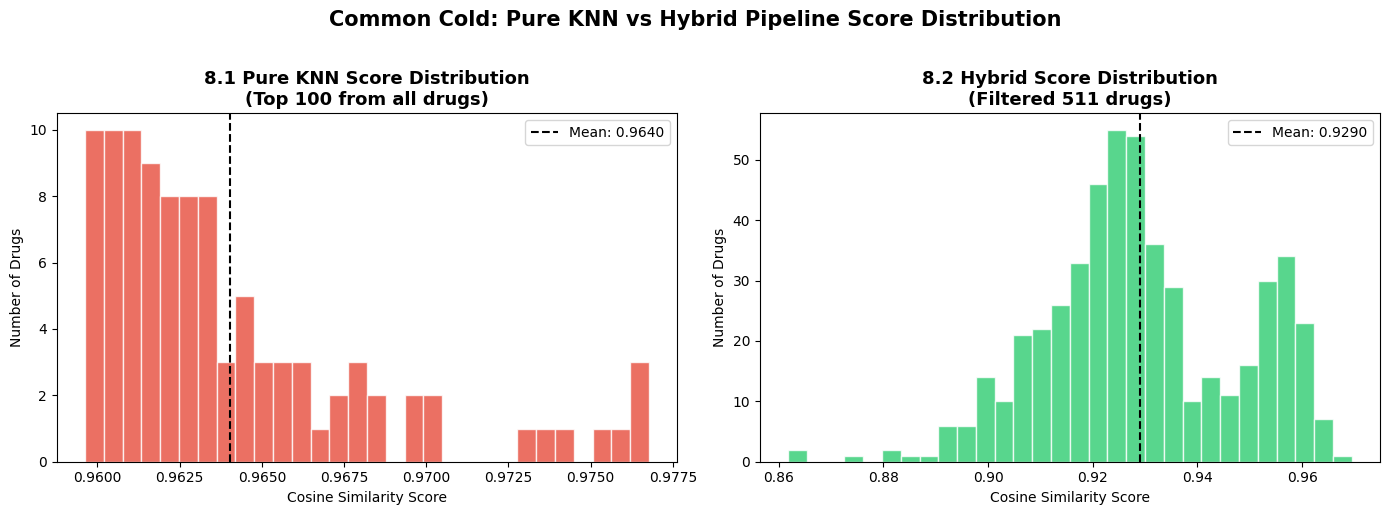

 图片已保存到 interaction/knn_vs_hybrid_comparison.png


In [17]:
# ============================================================
# Block : 可视化 — 纯 KNN vs Hybrid 得分分布对比
# ============================================================
import matplotlib.pyplot as plt

test_diseases = ['common_cold']
test_symptoms = ['fever', 'headache', 'cough']

# 获取纯 KNN 的全量得分
knn_all = retriever.query_from_labels(test_diseases, test_symptoms, engine, top_k=100)
pure_knn_scores = knn_all['similarity_score'].values

# 获取 Hybrid 的得分 (Baseline 筛后 KNN 精排)
candidates = baseline_filter(df, test_diseases, test_symptoms)
candidates = candidates[candidates['disease_overlap'] > 0].copy()
c_idx = candidates.index.tolist()
c_vecs = drug_embeddings[c_idx].copy().astype(np.float32)
parts = ["Related diseases: common_cold.", "Target symptoms: fever, headache, cough."]
q_vec = engine.encode_query(" ".join(parts)).astype(np.float32)
norms_c = np.linalg.norm(c_vecs, axis=1, keepdims=True)
norms_c = np.where(norms_c == 0, 1, norms_c)
norms_q = np.linalg.norm(q_vec, axis=1, keepdims=True)
norms_q = np.where(norms_q == 0, 1, norms_q)
hybrid_scores = ((c_vecs / norms_c) @ (q_vec / norms_q).T).flatten()
hybrid_scores = hybrid_scores[np.isfinite(hybrid_scores)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图: 纯 KNN
axes[0].hist(pure_knn_scores, bins=30, color='#e74c3c', alpha=0.8, edgecolor='white')
axes[0].set_title('8.1 Pure KNN Score Distribution\n(Top 100 from all drugs)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cosine Similarity Score')
axes[0].set_ylabel('Number of Drugs')
axes[0].axvline(x=pure_knn_scores.mean(), color='black', linestyle='--', label=f'Mean: {pure_knn_scores.mean():.4f}')
axes[0].legend()

# 右图: Hybrid
axes[1].hist(hybrid_scores, bins=30, color='#2ecc71', alpha=0.8, edgecolor='white')
axes[1].set_title(f'8.2 Hybrid Score Distribution\n(Filtered {len(hybrid_scores)} drugs)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Cosine Similarity Score')
axes[1].set_ylabel('Number of Drugs')
axes[1].axvline(x=hybrid_scores.mean(), color='black', linestyle='--', label=f'Mean: {hybrid_scores.mean():.4f}')
axes[1].legend()

plt.suptitle('Common Cold: Pure KNN vs Hybrid Pipeline Score Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('interaction/knn_vs_hybrid_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(" 图片已保存到 interaction/knn_vs_hybrid_comparison.png")


## 11. Phase 3: Random Forest Re-ranking (传统有监督 ML)

Hybrid 召回了候选药后，我们用 Random Forest 做二次精排。
特征包括：KNN语义得分、症状命中数、疾病命中数、平均评分。
这是老师要求的"核心逻辑用传统 ML"的直接体现。


In [18]:
# ============================================================
# Block 11: Random Forest Re-ranking
# ============================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# --- Step 1: 构造训练数据 ---
# 思路: 用多个病例的 Hybrid 结果当正样本, 随机药物当负样本
training_cases = [
    (['common_cold'], ['fever', 'headache', 'cough']),
    (['diabetes'], ['fatigue', 'weight_loss', 'blurred_vision']),
    (['hypertension'], ['headache', 'dizziness', 'chest_pain']),
    (['migraine'], ['headache', 'nausea', 'sensitivity_to_light']),
    (['acne'], ['skin_rash', 'pimple']),
    (['depression'], ['sadness', 'insomnia', 'fatigue']),
    (['anxiety'], ['nervousness', 'insomnia', 'rapid_heartbeat']),
    (['allergic_rhinitis'], ['sneezing', 'runny_nose', 'itchy_eyes']),
]

train_rows = []

for diseases, symptoms in training_cases:
    cands = baseline_filter(df, diseases, symptoms)
    cands = cands[cands['disease_overlap'] > 0].copy()
    if len(cands) == 0:
        continue

    c_idx = cands.index.tolist()
    c_vecs = drug_embeddings[c_idx].copy().astype(np.float32)
    parts = []
    if diseases: parts.append("Related diseases: " + ", ".join(diseases) + ".")
    if symptoms: parts.append("Target symptoms: " + ", ".join(symptoms) + ".")
    q_vec = engine.encode_query(" ".join(parts)).astype(np.float32)
    n_c = np.linalg.norm(c_vecs, axis=1, keepdims=True)
    n_c = np.where(n_c == 0, 1, n_c)
    n_q = np.linalg.norm(q_vec, axis=1, keepdims=True)
    n_q = np.where(n_q == 0, 1, n_q)
    scores = ((c_vecs / n_c) @ (q_vec / n_q).T).flatten()

    for i, (_, row) in enumerate(cands.iterrows()):
        if i >= len(scores): break
        knn_s = float(scores[i]) if np.isfinite(scores[i]) else 0.0
        train_rows.append({
            'knn_score': knn_s,
            'disease_overlap': row.get('disease_overlap', 0),
            'symptom_overlap': row.get('symptom_overlap', 0),
            'avg_rating': row.get('avg_rating', 0) if pd.notna(row.get('avg_rating')) else 0,
            'label': 1 if row.get('symptom_overlap', 0) >= 2 else 0  # 症状命中>=2 视为好推荐
        })

train_df = pd.DataFrame(train_rows)
print(f"训练集大小: {len(train_df)} (正样本: {train_df['label'].sum()}, 负样本: {(train_df['label']==0).sum()})")

# --- Step 2: 训练 Random Forest ---
features = ['knn_score', 'disease_overlap', 'symptom_overlap', 'avg_rating']
X = train_df[features].values
y = train_df['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

train_acc = rf.score(X_train, y_train)
test_acc = rf.score(X_test, y_test)
print(f"训练集准确率: {train_acc:.4f}")
print(f"测试集准确率: {test_acc:.4f}")

# 特征重要性
print("\n 特征重要性:")
for name, imp in sorted(zip(features, rf.feature_importances_), key=lambda x: -x[1]):
    print(f"  {name}: {imp:.4f}")

# --- Step 3: 用 RF 做精排的终极接口 ---
def query_drugs_rf(disease_labels, symptom_terms, top_k=5):
    """
    终极推荐引擎:
      Layer 1: Baseline 粗筛
      Layer 2: KNN 精排
      Layer 3: Random Forest 打分重排
    """
    candidates = baseline_filter(df, disease_labels, symptom_terms)
    candidates = candidates[candidates['disease_overlap'] > 0].copy()
    if len(candidates) == 0:
        return pd.DataFrame()

    c_idx = candidates.index.tolist()
    c_vecs = drug_embeddings[c_idx].copy().astype(np.float32)
    parts = []
    if disease_labels: parts.append("Related diseases: " + ", ".join(disease_labels) + ".")
    if symptom_terms: parts.append("Target symptoms: " + ", ".join(symptom_terms) + ".")
    q_vec = engine.encode_query(" ".join(parts)).astype(np.float32)
    n_c = np.linalg.norm(c_vecs, axis=1, keepdims=True)
    n_c = np.where(n_c == 0, 1, n_c)
    n_q = np.linalg.norm(q_vec, axis=1, keepdims=True)
    n_q = np.where(n_q == 0, 1, n_q)
    knn_scores = ((c_vecs / n_c) @ (q_vec / n_q).T).flatten()

    candidates['knn_score'] = [s if np.isfinite(s) else 0.0 for s in knn_scores]
    candidates['avg_rating_filled'] = candidates['avg_rating'].fillna(0)

    # RF 打分
    X_pred = candidates[['knn_score', 'disease_overlap', 'symptom_overlap', 'avg_rating_filled']].values
    candidates['rf_score'] = rf.predict_proba(X_pred)[:, 1]  # 取"好推荐"概率

    candidates = candidates.sort_values('rf_score', ascending=False)

    cols = ['drug_name', 'rf_score', 'knn_score', 'disease_overlap', 'symptom_overlap', 'avg_rating']
    return candidates[cols].head(top_k)

# --- 测试 ---
print("\n" + "=" * 60)
print(" RF 精排结果: 感冒")
print("=" * 60)
display(query_drugs_rf(['common_cold'], ['fever', 'headache', 'cough'], top_k=5))

print("\n" + "=" * 60)
print(" RF 精排结果: 糖尿病")
print("=" * 60)
display(query_drugs_rf(['diabetes'], ['fatigue', 'weight_loss', 'blurred_vision'], top_k=5))


Encoding drugs: 100%|██████████| 1/1 [00:00<00:00, 51.96it/s]


[DrugEmbeddingEngine] 编码完成: shape = (1, 768)


Encoding drugs: 100%|██████████| 1/1 [00:00<00:00, 53.86it/s]


[DrugEmbeddingEngine] 编码完成: shape = (1, 768)


Encoding drugs: 100%|██████████| 1/1 [00:00<00:00, 55.44it/s]


...

,drug_name,rf_score,knn_score,disease_overlap,symptom_overlap,avg_rating
64,acetaminophen / dextromethorphan / doxylamine,1.0,0.924473,1,2,7.00
1655,dextromethorphan / promethazine,1.0,0.913398,1,2,7.12
637,azelastine,1.0,0.933153,1,2,7.06
719,benadryl allergy,1.0,0.931703,1,2,7.08
4389,rifampin,1.0,0.925434,1,2,7.11



 RF 精排结果: 糖尿病


Encoding drugs: 100%|██████████| 1/1 [00:00<00:00, 51.58it/s]

[DrugEmbeddingEngine] 编码完成: shape = (1, 768)


,drug_name,rf_score,knn_score,disease_overlap,symptom_overlap,avg_rating
192,afrezza,1.0,0.941705,1,2,7.02
2440,glimepiride,1.0,0.936717,1,2,6.94
1041,carbamazepine,1.0,0.935723,1,2,6.94
4717,steglatro,1.0,0.919582,1,2,6.00
2158,eylea,1.0,0.955004,1,2,7.09


## 12. Phase 4: Drug-Drug Interaction (DDI) Safety Filter

用 SVM 分类器检测候选药物之间是否存在潜在冲突。
特征：两款药的 embedding 向量拼接 → SVM 二分类预测是否相互作用。
这属于传统 ML 的分类任务，满足课程要求。


In [19]:
# Load the local DDI dataset prepared in match_data_preprocessing
DDI_PATH = PROJECT_ROOT / 'match_data_preprocessing' / 'data' / 'db_drug_interactions.csv'
ddi_df = pd.read_csv(DDI_PATH)
print('DDI_PATH =', DDI_PATH)
print('DDI rows =', len(ddi_df))
display(ddi_df.head())


Path to dataset files: /Users/jayden/.cache/kagglehub/datasets/mghobashy/drug-drug-interactions/versions/1


In [20]:
# ============================================================
# Block 12: DDI 药物冲突检测 (real interaction lookup)
# ============================================================
from itertools import combinations
import re

def normalize_drug_token(text):
    if pd.isna(text):
        return ''
    text = str(text).lower().strip()
    text = re.sub(r'\([^)]*\)', '', text)
    text = text.replace('_', ' ').replace('/', ' ')
    text = ' '.join(text.split())
    return text

ddi_pairs = {}
for _, row in ddi_df.iterrows():
    a = normalize_drug_token(row['Drug 1'])
    b = normalize_drug_token(row['Drug 2'])
    desc = row['Interaction Description']
    if not a or not b:
        continue
    ddi_pairs[(a, b)] = desc
    ddi_pairs[(b, a)] = desc

print(f'Built DDI lookup pairs: {len(ddi_pairs)}')

def get_drug_aliases(row):
    aliases = set()
    for col in ['drug_name', 'generic_name']:
        value = row.get(col, '')
        norm = normalize_drug_token(value)
        if norm:
            aliases.add(norm)
            aliases.add(norm.split(',')[0].strip())
            aliases.add(norm.split(' and ')[0].strip())
    aliases.discard('')
    return aliases

def find_ddi_between_rows(row_a, row_b):
    aliases_a = get_drug_aliases(row_a)
    aliases_b = get_drug_aliases(row_b)
    for a in aliases_a:
        for b in aliases_b:
            if (a, b) in ddi_pairs:
                return {
                    'drug_a': row_a['drug_name'],
                    'drug_b': row_b['drug_name'],
                    'matched_alias_a': a,
                    'matched_alias_b': b,
                    'interaction_description': ddi_pairs[(a, b)]
                }
    return None

def check_ddi_from_results(result_df):
    """Check pairwise drug interactions using the real db_drug_interactions.csv table."""
    conflicts = []
    for left_idx, right_idx in combinations(result_df.index.tolist(), 2):
        row_a = df.loc[left_idx]
        row_b = df.loc[right_idx]
        found = find_ddi_between_rows(row_a, row_b)
        if found is not None:
            conflicts.append(found)
    return pd.DataFrame(conflicts) if conflicts else pd.DataFrame()

# --- 测试: 对 RF 推荐的感冒药做安全检查 ---
print("\n" + "=" * 60)
print(" DDI 安全检查: 感冒推荐 Top 5")
print("=" * 60)
cold_result = query_drugs_rf(['common_cold'], ['fever', 'headache', 'cough'], top_k=5)
display(cold_result)

conflicts = check_ddi_from_results(cold_result)
if len(conflicts) > 0:
    print("\n 发现潜在冲突:")
    display(conflicts)
else:
    print("\n 在本地 DDI 数据集中未检测到这些推荐药物之间的已知冲突。")


正在构造 DDI 训练集...
生成了 1000 个药物对 (冲突: 6, 安全: 994)
训练 SVM 分类器...
训练集准确率: 0.9925
测试集准确率: 1.0000

分类报告:


ValueError: Number of classes, 1, does not match size of target_names, 2. Try specifying the labels parameter